# Some Experiments to Understand how a Pytorch Optimizer works

In [30]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

from tqdm import tqdm

from experimental_optimizers.soap import SOAP

Let's generate a simple 1D regression problem

In [31]:
x = np.linspace(-np.pi, np.pi, 1000)
y = np.sin(x)*np.sin(2*x)

And visualize it

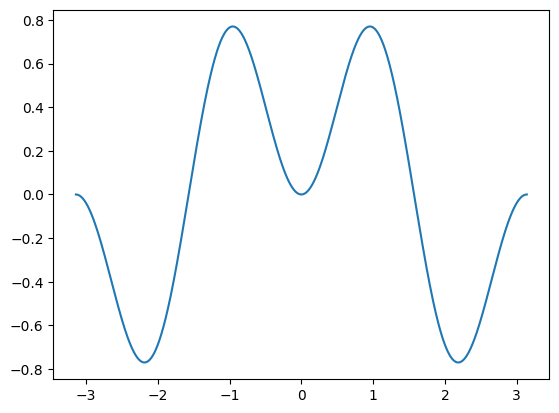

In [32]:
plt.plot(x, y)

Now let's create a simple NN model

In [33]:
class LinearNN(nn.Module):
    def __init__(self, hidden_size: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32, bias=True),
            nn.ReLU(),
            nn.Linear(32, hidden_size, bias=True),
            nn.ReLU(),
            nn.Linear(hidden_size, 1, bias=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

Create the training and testing datasets, then create a training loop

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train.reshape(-1, 1))
x_test = scaler.transform(x_test.reshape(-1, 1))

X_train = torch.from_numpy(x_train).float()
Y_train = torch.from_numpy(y_train).float().unsqueeze(1)
X_test = torch.from_numpy(x_test).float()
Y_test = torch.from_numpy(y_test).float().unsqueeze(1)

In [35]:
loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=True)
model = LinearNN()
criterion = nn.MSELoss()

optimiser = SOAP(model.parameters(), lr=0.001, betas = (0.9, 0.999), weight_decay=0.01)

epochs = 200

In [36]:
optimiser

SOAP (
Parameter Group 0
    betas: (0.9, 0.999)
    correct_bias: True
    eps: 1e-08
    lr: 0.001
    max_precond_dim: 10000
    merge_dims: False
    normalize_grads: False
    precondition_1d: False
    precondition_frequency: 10
    shampoo_beta: -1
    weight_decay: 0.01
)

In [37]:

print(f"Training with optimiser {optimiser.__class__.__name__}")

pbar = tqdm(range(epochs), desc="Training",)
for epoch in pbar:
    epoch_loss = 0.0
    for x_batch, y_batch in loader:
        optimiser.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item() * len(x_batch)

    epoch_loss /= len(X_train)
    if (epoch) % 10 == 0:
        pbar.set_postfix(mse=f"{epoch_loss:.6f}")

Training with optimiser SOAP


Training: 100%|██████████| 200/200 [00:04<00:00, 43.16it/s, mse=0.000158]


Test the model

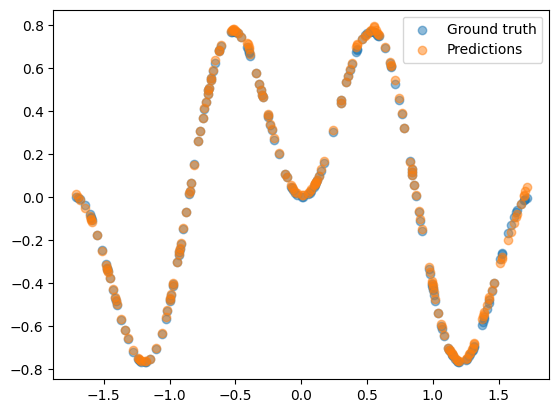

In [38]:
model.eval()
with torch.no_grad():
    preds = model(X_test).squeeze(1).numpy()

plt.scatter(x_test, y_test, label="Ground truth", alpha=0.5)
plt.scatter(x_test, preds, label="Predictions", alpha=0.5)
plt.legend()

## Optimizer data storage

In [39]:
optstate = optimiser.state_dict()

In [40]:
print(len(loader.dataset))
print(loader.batch_size)
print(epochs)
print(len(loader.dataset) // loader.batch_size * epochs)

800
32
200
5000


In [41]:
optstate['state'][0]['step']

4999

At each epoch, step is updated at every presentation of a batch
$$
steps = \frac{\# x_{test}}{\# batch} \times epochs
$$

In [42]:
optstate['state'][0].keys()

dict_keys(['step', 'exp_avg', 'exp_avg_sq', 'GG', 'Q', 'precondition_frequency', 'shampoo_beta'])

Adam keeps track of the exponentially averaged gradients and its square

In [43]:
optstate['param_groups'][0].keys()

dict_keys(['lr', 'betas', 'shampoo_beta', 'eps', 'weight_decay', 'precondition_frequency', 'max_precond_dim', 'merge_dims', 'precondition_1d', 'normalize_grads', 'correct_bias', 'params'])

param_groups is a list of dictionaries with one element.

In [44]:
optstate['param_groups'][0]

{'lr': 0.001,
 'betas': (0.9, 0.999),
 'shampoo_beta': -1,
 'eps': 1e-08,
 'weight_decay': 0.01,
 'precondition_frequency': 10,
 'max_precond_dim': 10000,
 'merge_dims': False,
 'precondition_1d': False,
 'normalize_grads': False,
 'correct_bias': True,
 'params': [0, 1, 2, 3, 4, 5]}

Now, what is params? Why its elements are the keys of 'state'?

In [45]:
print(model)
for p in optstate['param_groups'][0]['params']:
    print(optstate['state'][p]['exp_avg_sq'].shape)

LinearNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
torch.Size([32, 1])
torch.Size([32])
torch.Size([64, 32])
torch.Size([64])
torch.Size([1, 64])
torch.Size([1])


In [46]:
print(optimiser)

SOAP (
Parameter Group 0
    betas: (0.9, 0.999)
    correct_bias: True
    eps: 1e-08
    lr: 0.001
    max_precond_dim: 10000
    merge_dims: False
    normalize_grads: False
    precondition_1d: False
    precondition_frequency: 10
    shampoo_beta: -1
    weight_decay: 0.01
)


In [47]:
for param_group in optimiser.param_groups:
    for param in param_group['params']:
        print(param.shape)

torch.Size([32, 1])
torch.Size([32])
torch.Size([64, 32])
torch.Size([64])
torch.Size([1, 64])
torch.Size([1])


In [48]:
for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"{name}: {param.grad.shape}")

net.0.weight: torch.Size([32, 1])
net.0.bias: torch.Size([32])
net.2.weight: torch.Size([64, 32])
net.2.bias: torch.Size([64])
net.4.weight: torch.Size([1, 64])
net.4.bias: torch.Size([1])


In [49]:
namedpars = list(model.named_parameters())

In [50]:
namedpars[2][1]

Parameter containing:
tensor([[ 0.0163,  0.0171,  0.2075,  ..., -0.0286,  0.4074, -0.1198],
        [-0.1177, -0.0402, -0.0691,  ..., -0.2637, -0.2862,  0.0559],
        [-0.1559,  0.0412,  0.0298,  ..., -0.0872, -0.1576,  0.1340],
        ...,
        [ 0.1227,  0.4305, -0.1170,  ...,  0.0639, -0.1062, -0.0429],
        [ 0.0492, -0.0070,  0.1401,  ..., -0.2062, -0.1540, -0.0348],
        [ 0.1155, -0.5065,  0.1525,  ...,  0.0531,  0.5925, -0.2128]],
       requires_grad=True)

`params` enumerates the NN layers: state is kept for each layer in `optstate['state'][p]` where p is in params, e.g. for the first layer, the grandient, square gradient, preconditioners etc, are kept in the dictionary at `optstate['state'][0]`

## Preconditioning

Ok fine, now let's try to extract the preconditioners in the case of SOAP

In [51]:
if str(optimiser)[0:4] == "SOAP":
    print("This is a SOAP optimiser.\nYou can access the preconditioner.")
else:
    print("This is not a SOAP optimiser.")

This is a SOAP optimiser.
You can access the preconditioner.


In [52]:
print(model)
for p in optstate['param_groups'][0]['params']:
    for mat in optstate['state'][p]['Q']:
        if isinstance(mat, torch.Tensor):
            print(f"{p}: {mat.shape}")
        else:
            print(f"{p}: {mat}")

LinearNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
0: torch.Size([32, 32])
0: torch.Size([1, 1])
1: []
2: torch.Size([64, 64])
2: torch.Size([32, 32])
3: []
4: torch.Size([1, 1])
4: torch.Size([64, 64])
5: []


Ok, shape makes sense for the preconditioners. Bias layers have an empty list as a preconditioner... why?
Because `precodition_1d = False`, while if it is set to `True` also 1D gradients will be preconditioned, like the ones for bias

In [53]:
print(model)
for p in optstate['param_groups'][0]['params']:
    for mat in optstate['state'][p]['GG']:
        if isinstance(mat, torch.Tensor):
            print(f"{p}: {mat.shape}")
        else:
            print(f"{p}: {mat}")

LinearNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
0: torch.Size([32, 32])
0: torch.Size([1, 1])
1: []
2: torch.Size([64, 64])
2: torch.Size([32, 32])
3: []
4: torch.Size([1, 1])
4: torch.Size([64, 64])
5: []


In [54]:
optstate['state'][2]['GG'][1].shape

torch.Size([32, 32])

A bit of experiments with projectors to get a gist of the preconditioning: projection is $G' = Q^T_L G Q_R$

In [55]:
v = torch.randn(3).unsqueeze_(1)
m = torch.randn(3, 2)
projector = torch.from_numpy(np.eye(3)[0:2,:]).float()

projecting a column vector of 3 elements to a 2-dimensional space and trying to obtain the same results with @ and tensordot

In [56]:
print(f"v:\n{v}")
print(f"projector:\n{projector}")
print(f"projected v (@):\n{projector @ v}")
print(f"projected v (tensordot):\n{torch.tensordot(projector, v, dims=1)}")

v:
tensor([[0.1893],
        [2.1092],
        [1.5801]])
projector:
tensor([[1., 0., 0.],
        [0., 1., 0.]])
projected v (@):
tensor([[0.1893],
        [2.1092]])
projected v (tensordot):
tensor([[0.1893],
        [2.1092]])


projecting a 3 $\times$ 2 matrix to a 2 $\times$ 2  matrices space

In [57]:
print(f"m:\n{m}")
print(f"projector:\n{projector}")
print(f"projected m:\n{projector @ m}")
print(f"projected m (tensordot):\n{torch.tensordot(projector, m, dims=([1], [0]))}")

m:
tensor([[-2.0110, -0.5846],
        [ 1.6073, -0.9934],
        [ 0.3486, -0.0388]])
projector:
tensor([[1., 0., 0.],
        [0., 1., 0.]])
projected m:
tensor([[-2.0110, -0.5846],
        [ 1.6073, -0.9934]])
projected m (tensordot):
tensor([[-2.0110, -0.5846],
        [ 1.6073, -0.9934]])


In [58]:
torch.tensordot(m,m, dims = ([0], [0]))

tensor([[ 6.7492, -0.4345],
        [-0.4345,  1.3301]])

In [59]:
L = m @ m.transpose(0,1)
R = m.transpose(0,1) @ m
Ql = (torch.linalg.eigh(L).eigenvectors).flip([1])
Qr = (torch.linalg.eigh(R).eigenvectors).flip([1])

In [60]:
(Ql.transpose(0,1) @ m) @ Qr

tensor([[-2.6046e+00,  7.4506e-08],
        [-9.6858e-08,  1.1382e+00],
        [ 1.2721e-08, -1.5968e-07]])

In [61]:
torch.linalg.svd(m)

torch.return_types.linalg_svd(
U=tensor([[-0.7519, -0.6523,  0.0958],
        [ 0.6454, -0.7579, -0.0951],
        [ 0.1346, -0.0097,  0.9909]]),
S=tensor([2.6046, 1.1382]),
Vh=tensor([[ 0.9968, -0.0794],
        [ 0.0794,  0.9968]]))

$G' = Q^T_L G Q_R$ Is computing a sungular value decomposition of G!
This is true for a single step, while in the real case, being G an exponential moving average, this is not exact.
[A similar algorithm is [GaLore](https://arxiv.org/abs/2403.03507)]

In [62]:
import itertools
idx = 0
[[*itertools.chain(range(idx), range(idx + 1, len(m.shape)))]] * 2

[[1], [1]]

In [63]:
torch.linalg.eigh(Ql)

torch.return_types.linalg_eigh(
eigenvalues=tensor([-0.9978,  0.9417,  1.0529]),
eigenvectors=tensor([[ 0.9369,  0.2057,  0.2827],
        [-0.3441,  0.6854,  0.6417],
        [-0.0617, -0.6985,  0.7130]]))

In [64]:
torch.tensordot(m, m, dims=([[1], [1]]))

tensor([[ 4.3861, -2.6515, -0.6783],
        [-2.6515,  3.5702,  0.5988],
        [-0.6783,  0.5988,  0.1230]])

In [65]:
m @ m.transpose(0,1)

tensor([[ 4.3861, -2.6515, -0.6783],
        [-2.6515,  3.5702,  0.5988],
        [-0.6783,  0.5988,  0.1230]])

In [66]:
mp = m
for mat in [Ql, Qr]:
    mp = torch.tensordot(mp, mat, dims=([[0], [0]]))

mp

tensor([[-2.6046e+00,  7.4506e-08],
        [-9.6858e-08,  1.1382e+00],
        [ 1.2721e-08, -1.5968e-07]])

In [67]:
torch.flip(mp, [1])

tensor([[ 7.4506e-08, -2.6046e+00],
        [ 1.1382e+00, -9.6858e-08],
        [-1.5968e-07,  1.2721e-08]])